In [6]:
import cv2
import numpy as np
import os

# ==============================
# SETTINGS
# ==============================
image_path    = r"D:\projects\neuro\all fascicles\fascicle images\set1_Image02_40x_bf_03_fascicle_All\2.png"
output_folder = r"D:\projects\neuro\patches\40x_bf_03_all_2"
output_folder_discarded = r"D:\projects\neuro\patches\40x_bf_03_all_2_discarded"
patch_size    = 128
stride        = 64
MIN_AXONS_PER_PATCH = 1

# ==============================
# AXON DETECTION PARAMS
# (same as your main pipeline)
# ==============================
scale_factor       = 0.136
TISSUE_OVERLAP_MIN = 0.50
MIN_CIRCULARITY    = 0.05
MIN_CONTOUR_AREA   = 8
MAX_CONTOUR_AREA   = 2000000
MIN_SOLIDITY       = 0.15


# ==============================
# HELPERS (from your main code)
# ==============================
def darken_and_sharpen(image):
    darkened = cv2.convertScaleAbs(image, alpha=1.5, beta=-20)
    sharpen_kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
    return cv2.filter2D(darkened, -1, sharpen_kernel)


def build_tissue_mask(full_image):
    hsv = cv2.cvtColor(full_image, cv2.COLOR_BGR2HSV)
    H, S, V = cv2.split(hsv)
    sat_mask       = cv2.inRange(S, 15, 255)
    not_too_bright = cv2.inRange(V, 0, 250)
    mask = cv2.bitwise_and(sat_mask, not_too_bright)
    k    = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  k, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k, iterations=2)
    return mask


def contour_overlap_ratio(contour, mask):
    c_mask = np.zeros(mask.shape, dtype=np.uint8)
    cv2.drawContours(c_mask, [contour], -1, 255, -1)
    inter  = cv2.bitwise_and(c_mask, mask)
    area_c = cv2.countNonZero(c_mask)
    area_i = cv2.countNonZero(inter)
    return area_i / float(area_c) if area_c > 0 else 0.0


def circularity(contour):
    a = cv2.contourArea(contour)
    p = cv2.arcLength(contour, True)
    return 4 * np.pi * a / (p * p + 1e-6) if p > 0 else 0


# ==============================
# STEP 1: Detect all axon centers
# on the FULL image (one time only)
# ==============================
def detect_axon_centers(image):
    """
    Runs detection on the full image once and returns a list of (cx, cy)
    for every valid axon — same filters as your main pipeline.
    No thickness measurement, just centers.
    """
    tissue_mask = build_tissue_mask(image)
    h, w = image.shape[:2]
    detect_patch_size = 1024   # same tiling as your main code

    centers = []

    for y in range(0, h, detect_patch_size):
        for x in range(0, w, detect_patch_size):
            patch      = image[y:y + detect_patch_size, x:x + detect_patch_size]
            mask_patch = tissue_mask[y:y + detect_patch_size, x:x + detect_patch_size]

            patch = darken_and_sharpen(patch)
            gray  = cv2.cvtColor(patch, cv2.COLOR_BGR2GRAY)

            smooth   = cv2.bilateralFilter(gray, 5, 20, 20)
            clahe    = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
            enhanced = clahe.apply(smooth)
            blurred  = cv2.GaussianBlur(enhanced, (3, 3), 0)

            _, otsu = cv2.threshold(blurred, 0, 255,
                                    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
            adaptive = cv2.adaptiveThreshold(
                blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                cv2.THRESH_BINARY_INV, 35, 2
            )
            thresh = cv2.bitwise_or(otsu, adaptive)

            kernel  = np.ones((3, 3), np.uint8)
            opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)
            sure_bg = cv2.dilate(opening, kernel, iterations=3)

            dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
            if dist_transform.max() > 0:
                _, sure_fg = cv2.threshold(dist_transform,
                                           0.4 * dist_transform.max(), 255, 0)
            else:
                sure_fg = np.zeros_like(opening)
            sure_fg = np.uint8(sure_fg)

            unknown    = cv2.subtract(sure_bg, sure_fg)
            _, markers = cv2.connectedComponents(sure_fg)
            markers    = markers + 1
            markers[unknown == 255] = 0

            wshed_input = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2BGR)
            markers     = cv2.watershed(wshed_input, markers)

            cleaned = thresh.copy()
            cleaned[markers == -1] = 0

            contours, hierarchy = cv2.findContours(
                cleaned, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE
            )
            if hierarchy is None:
                continue
            hierarchy = hierarchy[0]

            for i, contour in enumerate(contours):
                if hierarchy[i][3] != -1:
                    continue

                area = cv2.contourArea(contour)
                if area < MIN_CONTOUR_AREA or area > MAX_CONTOUR_AREA:
                    continue

                if contour_overlap_ratio(contour, mask_patch) < TISSUE_OVERLAP_MIN:
                    continue

                hull     = cv2.convexHull(contour)
                solidity = area / (cv2.contourArea(hull) + 1e-6)
                if solidity < MIN_SOLIDITY or circularity(contour) < MIN_CIRCULARITY:
                    continue

                # must have at least one inner contour (myelin ring)
                has_inner = any(
                    hierarchy[j][3] == i and cv2.contourArea(contours[j]) > 30
                    for j in range(len(contours))
                )
                if not has_inner:
                    continue

                # Store center in FULL image coordinates
                (cx_local, cy_local), _ = cv2.minEnclosingCircle(contour)
                centers.append((cx_local + x, cy_local + y))

    return centers   # list of (cx, cy) floats in full-image pixel space


# ==============================
# STEP 2: Slice into 128x128 patches.
# For each patch, count how many
# axon centers fall inside it.
# Save only if count >= min_axons.
# ==============================
def extract_validated_patches(image_path, output_folder, output_folder_discarded, patch_size, stride, min_axons):
    os.makedirs(output_folder, exist_ok=True)
    os.makedirs(output_folder_discarded, exist_ok=True)

    image = cv2.imread(image_path)
    if image is None:
        print(f"❌  Cannot read image: {image_path}")
        return

    h, w = image.shape[:2]
    print(f"Image size      : {w} x {h} px")
    print(f"Patch size      : {patch_size} x {patch_size}  |  Stride : {stride}")
    print(f"Min axons/patch : {min_axons}")
    print("\nStep 1 — Detecting axons on full image ...")

    # Detect once on the full image
    axon_centers = detect_axon_centers(image)
    centers_np   = np.array(axon_centers) if axon_centers else np.empty((0, 2))
    print(f"  → {len(axon_centers)} axons detected in full image.\n")

    print("Step 2 — Slicing and filtering patches ...")
    total_chunks     = 0
    saved_chunks     = 0
    discarded_chunks = 0

    for y in range(0, h - patch_size + 1, stride):
        for x in range(0, w - patch_size + 1, stride):
            total_chunks += 1
            patch = image[y:y + patch_size, x:x + patch_size]

            # Count axon centers whose (cx, cy) falls inside this patch window
            if len(centers_np) > 0:
                inside = (
                    (centers_np[:, 0] >= x) & (centers_np[:, 0] < x + patch_size) &
                    (centers_np[:, 1] >= y) & (centers_np[:, 1] < y + patch_size)
                )
                n_axons = int(inside.sum())
            else:
                n_axons = 0

            if n_axons >= min_axons:
                patch_name = f"patch_{saved_chunks}_x{x}_y{y}_axons{n_axons}.png"
                cv2.imwrite(os.path.join(output_folder, patch_name), patch)
                saved_chunks += 1
            else:
                patch_name = f"patch_{discarded_chunks}_x{x}_y{y}_axons{n_axons}.png"
                cv2.imwrite(os.path.join(output_folder_discarded, patch_name), patch)
                discarded_chunks += 1

    # ── Summary ───────────────────────────────────────────────────────────────
    print("\n" + "=" * 48)
    print(f"  Total chunks generated   : {total_chunks}")
    print(f"  ✔ Saved  (>= {min_axons} axons)    : {saved_chunks}")
    print(f"  ✗ Discarded (< {min_axons} axons)  : {discarded_chunks}")
    print(f"  Saved folder             : {output_folder}")
    print(f"  Discarded folder         : {output_folder_discarded}")
    print("=" * 48)


# ==============================
# RUN
# ==============================
extract_validated_patches(image_path, output_folder, output_folder_discarded, patch_size, stride, MIN_AXONS_PER_PATCH)

Image size      : 2729 x 2822 px
Patch size      : 128 x 128  |  Stride : 64
Min axons/patch : 1

Step 1 — Detecting axons on full image ...
  → 374 axons detected in full image.

Step 2 — Slicing and filtering patches ...

  Total chunks generated   : 1763
  ✔ Saved  (>= 1 axons)    : 905
  ✗ Discarded (< 1 axons)  : 858
  Saved folder             : D:\projects\neuro\patches\40x_bf_03_all_2
  Discarded folder         : D:\projects\neuro\patches\40x_bf_03_all_2_discarded


In [12]:
import cv2
import numpy as np
import os

# ==============================
# SETTINGS
# ==============================
input_folder  = r"D:\projects\neuro\all fascicles\fascicle images\set1_image05_40x_bf_02_all"
output_root   = r"D:\projects\neuro\patches\40x_bf_02_all"
patch_size    = 128
stride        = 64
MIN_AXONS_PER_PATCH = 1

# ==============================
# AXON DETECTION PARAMS
# (same as your main pipeline)
# ==============================
scale_factor       = 0.136
TISSUE_OVERLAP_MIN = 0.50
MIN_CIRCULARITY    = 0.05
MIN_CONTOUR_AREA   = 8
MAX_CONTOUR_AREA   = 2000000
MIN_SOLIDITY       = 0.15


# ==============================
# HELPERS (from your main code)
# ==============================
def darken_and_sharpen(image):
    darkened = cv2.convertScaleAbs(image, alpha=1.5, beta=-20)
    sharpen_kernel = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
    return cv2.filter2D(darkened, -1, sharpen_kernel)


def build_tissue_mask(full_image):
    hsv = cv2.cvtColor(full_image, cv2.COLOR_BGR2HSV)
    H, S, V = cv2.split(hsv)
    sat_mask       = cv2.inRange(S, 15, 255)
    not_too_bright = cv2.inRange(V, 0, 250)
    mask = cv2.bitwise_and(sat_mask, not_too_bright)
    k    = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  k, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k, iterations=2)
    return mask


def contour_overlap_ratio(contour, mask):
    c_mask = np.zeros(mask.shape, dtype=np.uint8)
    cv2.drawContours(c_mask, [contour], -1, 255, -1)
    inter  = cv2.bitwise_and(c_mask, mask)
    area_c = cv2.countNonZero(c_mask)
    area_i = cv2.countNonZero(inter)
    return area_i / float(area_c) if area_c > 0 else 0.0


def circularity(contour):
    a = cv2.contourArea(contour)
    p = cv2.arcLength(contour, True)
    return 4 * np.pi * a / (p * p + 1e-6) if p > 0 else 0


# ==============================
# STEP 1: Detect all axon centers
# on the FULL image (one time only)
# ==============================
def detect_axon_centers(image):
    """
    Runs detection on the full image once and returns a list of (cx, cy)
    for every valid axon — same filters as your main pipeline.
    No thickness measurement, just centers.
    """
    tissue_mask = build_tissue_mask(image)
    h, w = image.shape[:2]
    detect_patch_size = 1024   # same tiling as your main code

    centers = []

    for y in range(0, h, detect_patch_size):
        for x in range(0, w, detect_patch_size):
            patch      = image[y:y + detect_patch_size, x:x + detect_patch_size]
            mask_patch = tissue_mask[y:y + detect_patch_size, x:x + detect_patch_size]

            patch = darken_and_sharpen(patch)
            gray  = cv2.cvtColor(patch, cv2.COLOR_BGR2GRAY)

            smooth   = cv2.bilateralFilter(gray, 5, 20, 20)
            clahe    = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
            enhanced = clahe.apply(smooth)
            blurred  = cv2.GaussianBlur(enhanced, (3, 3), 0)

            _, otsu = cv2.threshold(blurred, 0, 255,
                                    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
            adaptive = cv2.adaptiveThreshold(
                blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                cv2.THRESH_BINARY_INV, 35, 2
            )
            thresh = cv2.bitwise_or(otsu, adaptive)

            kernel  = np.ones((3, 3), np.uint8)
            opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)
            sure_bg = cv2.dilate(opening, kernel, iterations=3)

            dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
            if dist_transform.max() > 0:
                _, sure_fg = cv2.threshold(dist_transform,
                                           0.4 * dist_transform.max(), 255, 0)
            else:
                sure_fg = np.zeros_like(opening)
            sure_fg = np.uint8(sure_fg)

            unknown    = cv2.subtract(sure_bg, sure_fg)
            _, markers = cv2.connectedComponents(sure_fg)
            markers    = markers + 1
            markers[unknown == 255] = 0

            wshed_input = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2BGR)
            markers     = cv2.watershed(wshed_input, markers)

            cleaned = thresh.copy()
            cleaned[markers == -1] = 0

            contours, hierarchy = cv2.findContours(
                cleaned, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE
            )
            if hierarchy is None:
                continue
            hierarchy = hierarchy[0]

            for i, contour in enumerate(contours):
                if hierarchy[i][3] != -1:
                    continue

                area = cv2.contourArea(contour)
                if area < MIN_CONTOUR_AREA or area > MAX_CONTOUR_AREA:
                    continue

                if contour_overlap_ratio(contour, mask_patch) < TISSUE_OVERLAP_MIN:
                    continue

                hull     = cv2.convexHull(contour)
                solidity = area / (cv2.contourArea(hull) + 1e-6)
                if solidity < MIN_SOLIDITY or circularity(contour) < MIN_CIRCULARITY:
                    continue

                # must have at least one inner contour (myelin ring)
                has_inner = any(
                    hierarchy[j][3] == i and cv2.contourArea(contours[j]) > 30
                    for j in range(len(contours))
                )
                if not has_inner:
                    continue

                # Store center in FULL image coordinates
                (cx_local, cy_local), _ = cv2.minEnclosingCircle(contour)
                centers.append((cx_local + x, cy_local + y))

    return centers   # list of (cx, cy) floats in full-image pixel space


# ==============================
# STEP 2: Slice into 128x128 patches.
# For each patch, count how many
# axon centers fall inside it.
# Save only if count >= min_axons.
# ==============================
def extract_validated_patches(image_path, output_folder, output_folder_discarded, patch_size, stride, min_axons):
    os.makedirs(output_folder, exist_ok=True)
    os.makedirs(output_folder_discarded, exist_ok=True)

    image = cv2.imread(image_path)
    if image is None:
        print(f"❌  Cannot read image: {image_path}")
        return

    h, w = image.shape[:2]
    print(f"Image size      : {w} x {h} px")
    print(f"Patch size      : {patch_size} x {patch_size}  |  Stride : {stride}")
    print(f"Min axons/patch : {min_axons}")
    print("\nStep 1 — Detecting axons on full image ...")

    # Detect once on the full image
    axon_centers = detect_axon_centers(image)
    centers_np   = np.array(axon_centers) if axon_centers else np.empty((0, 2))
    print(f"  → {len(axon_centers)} axons detected in full image.\n")

    print("Step 2 — Slicing and filtering patches ...")
    total_chunks     = 0
    saved_chunks     = 0
    discarded_chunks = 0

    for y in range(0, h - patch_size + 1, stride):
        for x in range(0, w - patch_size + 1, stride):
            total_chunks += 1
            patch = image[y:y + patch_size, x:x + patch_size]

            # Count axon centers whose (cx, cy) falls inside this patch window
            if len(centers_np) > 0:
                inside = (
                    (centers_np[:, 0] >= x) & (centers_np[:, 0] < x + patch_size) &
                    (centers_np[:, 1] >= y) & (centers_np[:, 1] < y + patch_size)
                )
                n_axons = int(inside.sum())
            else:
                n_axons = 0

            if n_axons >= min_axons:
                patch_name = f"patch_{saved_chunks}_x{x}_y{y}_axons{n_axons}.png"
                cv2.imwrite(os.path.join(output_folder, patch_name), patch)
                saved_chunks += 1
            else:
                patch_name = f"patch_{discarded_chunks}_x{x}_y{y}_axons{n_axons}.png"
                cv2.imwrite(os.path.join(output_folder_discarded, patch_name), patch)
                discarded_chunks += 1

    # ── Summary ───────────────────────────────────────────────────────────────
    print("\n" + "=" * 48)
    print(f"  Total chunks generated   : {total_chunks}")
    print(f"  ✔ Saved  (>= {min_axons} axons)    : {saved_chunks}")
    print(f"  ✗ Discarded (< {min_axons} axons)  : {discarded_chunks}")
    print(f"  Saved folder             : {output_folder}")
    print(f"  Discarded folder         : {output_folder_discarded}")
    print("=" * 48)


# ==============================
# RUN — loop over all images
# ==============================
def process_folder(input_folder, output_root, patch_size, stride, min_axons):
    supported = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")
    images = [f for f in os.listdir(input_folder) if f.lower().endswith(supported)]

    if not images:
        print("❌  No images found in input folder.")
        return

    print(f"Found {len(images)} image(s) in: {input_folder}\n")

    for img_file in sorted(images):
        img_name    = os.path.splitext(img_file)[0]          # e.g. "1"
        image_path  = os.path.join(input_folder, img_file)

        # Two output folders per image: accepted + discarded
        out_accepted  = os.path.join(output_root, f"{img_name}_accepted")
        out_discarded = os.path.join(output_root, f"{img_name}_discarded")

        print("=" * 52)
        print(f"  Image : {img_file}")
        print(f"  → accepted  : {out_accepted}")
        print(f"  → discarded : {out_discarded}")
        print("=" * 52)

        extract_validated_patches(
            image_path, out_accepted, out_discarded,
            patch_size, stride, min_axons
        )
        print()

    print("🎉  All images processed.")


process_folder(input_folder, output_root, patch_size, stride, MIN_AXONS_PER_PATCH)

Found 10 image(s) in: D:\projects\neuro\all fascicles\fascicle images\set1_image05_40x_bf_02_all

  Image : 1.png
  → accepted  : D:\projects\neuro\patches\40x_bf_02_all\1_accepted
  → discarded : D:\projects\neuro\patches\40x_bf_02_all\1_discarded
Image size      : 1182 x 2243 px
Patch size      : 128 x 128  |  Stride : 64
Min axons/patch : 1

Step 1 — Detecting axons on full image ...
  → 47 axons detected in full image.

Step 2 — Slicing and filtering patches ...

  Total chunks generated   : 578
  ✔ Saved  (>= 1 axons)    : 156
  ✗ Discarded (< 1 axons)  : 422
  Saved folder             : D:\projects\neuro\patches\40x_bf_02_all\1_accepted
  Discarded folder         : D:\projects\neuro\patches\40x_bf_02_all\1_discarded

  Image : 10.png
  → accepted  : D:\projects\neuro\patches\40x_bf_02_all\10_accepted
  → discarded : D:\projects\neuro\patches\40x_bf_02_all\10_discarded
Image size      : 1426 x 1095 px
Patch size      : 128 x 128  |  Stride : 64
Min axons/patch : 1

Step 1 — Detect

In [14]:
import os
import shutil

# ===== INPUT & OUTPUT =====
INPUT_FOLDER  = r'D:\projects\neuro\patches\allpatches'
OUTPUT_FOLDER = r'D:\projects\neuro\patches\allpatches_renamed'

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# ===== Get sorted file list =====
files = sorted([f for f in os.listdir(INPUT_FOLDER)
                if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif'))])

# ===== Rename & copy =====
for i, file in enumerate(files, start=1):
    
    src_path = os.path.join(INPUT_FOLDER, file)
    
    # keep same extension
    ext = os.path.splitext(file)[1]
    
    new_name = f"{i}{ext}"
    dst_path = os.path.join(OUTPUT_FOLDER, new_name)

    shutil.copy(src_path, dst_path)

print("✅ Done!")
print("Saved in:", OUTPUT_FOLDER)

✅ Done!
Saved in: D:\projects\neuro\patches\allpatches_renamed


Excel saved at: D:\projects\neuro\patches\allpatches_renamed_blur_metrics.xlsx

Showing sample comparisons...


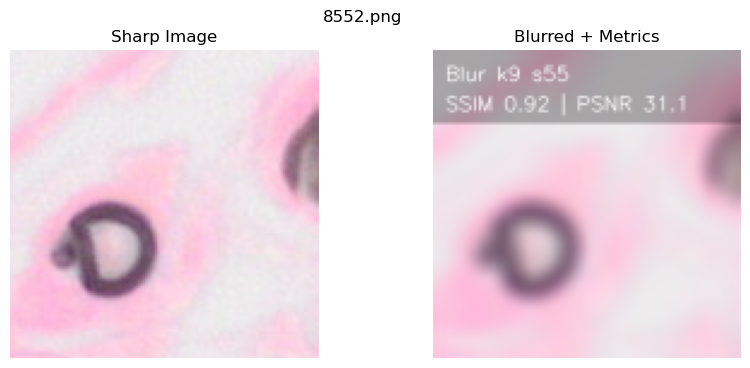

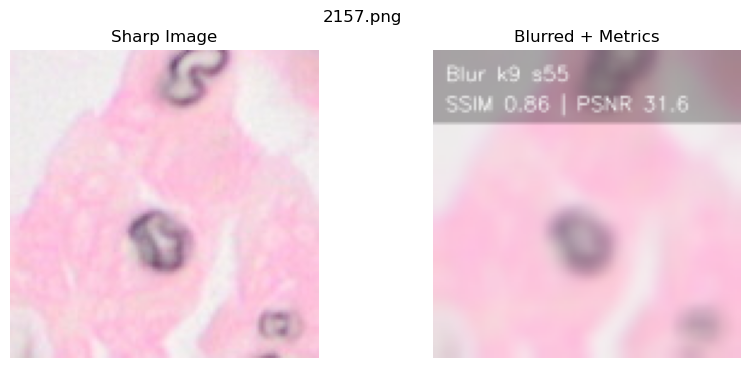

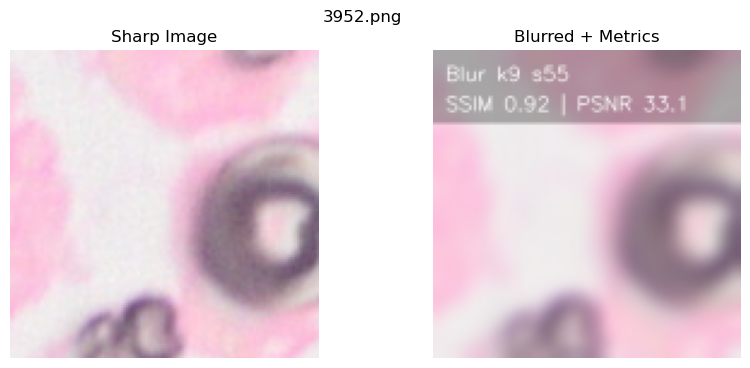

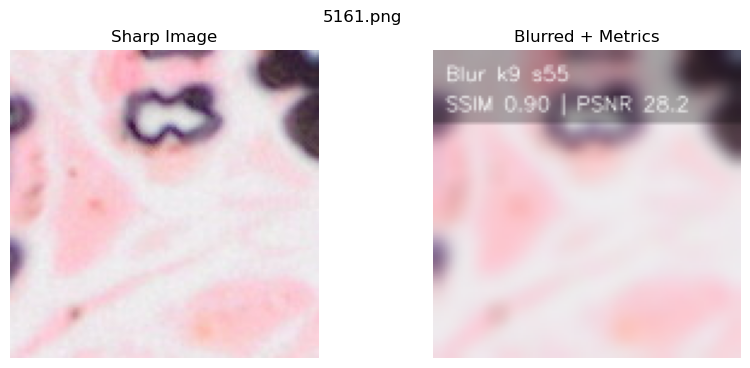

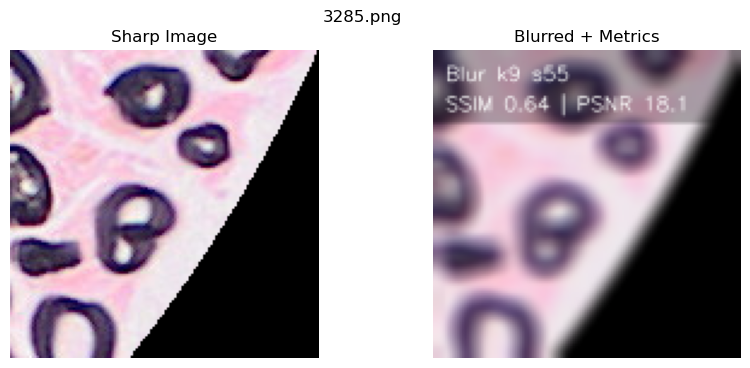

✅ Done!
Images saved at: D:\projects\neuro\patches\allpatches_blurred_with_metrics


In [21]:
import os
import cv2
import numpy as np
import pandas as pd
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
import random

# ====== Kaggle paths ======
INPUT_FOLDER  = r'D:\projects\neuro\patches\all patches\allpatches_renamed'
OUTPUT_FOLDER = r'D:\projects\neuro\patches\allpatches_blurred_with_metrics'

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# ====== SNR function ======
def compute_psnr(original, restored):
    original = original.astype(np.float64)
    restored = restored.astype(np.float64)

    mse = np.mean((original - restored) ** 2)
    
    if mse < 1e-10:
        return float('inf')
    
    return 20 * np.log10(255.0 / np.sqrt(mse))

# ====== Store metrics ======
records = []

# ====== Process images ======
for file in os.listdir(INPUT_FOLDER):

    if file.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif")):
        
        img_path = os.path.join(INPUT_FOLDER, file)
        img = cv2.imread(img_path)

        if img is None:
            print(f"Skipping: {file}")
            continue

        # ===== Blur =====
        blurred = cv2.GaussianBlur(img, (9, 9), 55)

        # ===== SSIM =====
        gray_orig = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        gray_blur = cv2.cvtColor(blurred, cv2.COLOR_BGR2GRAY)
        ssim_val = ssim(gray_orig, gray_blur, data_range=255)

        # ===== SNR =====
        psnr_val = compute_psnr(img, blurred)

        # ===== Clean + parse filename =====
        base = file.replace('.png', '')
        parts = base.split('_')

        try:
            patch = parts[1]
            x_val = parts[2].replace('x', '')
            y_val = parts[3].replace('y', '')
            axon  = parts[4]
        except:
            patch, x_val, y_val, axon = "NA", "NA", "NA", "NA"

        # ===== Save metrics =====
        records.append({
            "filename": file,
            "patch": patch,
            "x": x_val,
            "y": y_val,
            "axon_type": axon,
            "kernel_size": 9,
            "sigma": 55,
            "ssim": round(ssim_val, 4),
            "psnr": round(psnr_val, 2)
        })

        # ===== Anti-pixelated text (UPSCALE trick) =====
        h, w = blurred.shape[:2]
        scale_factor = 2

        big = cv2.resize(blurred, (w*scale_factor, h*scale_factor), interpolation=cv2.INTER_LINEAR)

        title = "Blur k9 s55"
        metrics = f"SSIM {ssim_val:.2f} | PSNR {psnr_val:.1f}"

        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 0.55
        thickness = 1

        x, y = 10, 25
        line_gap = 25

        # soft background
        overlay = big.copy()
        cv2.rectangle(overlay, (0, 0), (w*scale_factor, 60), (0, 0, 0), -1)
        big = cv2.addWeighted(overlay, 0.3, big, 0.7, 0)

        # draw smooth text
        cv2.putText(big, title, (x, y), font, font_scale, (255,255,255), thickness, cv2.LINE_AA)
        cv2.putText(big, metrics, (x, y + line_gap), font, font_scale, (255,255,255), thickness, cv2.LINE_AA)

        # downscale back
        blurred = cv2.resize(big, (w, h), interpolation=cv2.INTER_AREA)

        # ===== Save image =====
        save_path = os.path.join(OUTPUT_FOLDER, file)
        cv2.imwrite(save_path, blurred)

# ====== Save Excel ======
df = pd.DataFrame(records)
excel_path = r"D:\projects\neuro\patches\allpatches_renamed_blur_metrics.xlsx"
df.to_excel(excel_path, index=False, engine='openpyxl')

print("Excel saved at:", excel_path)

# ====== Visualization ======
print("\nShowing sample comparisons...")

valid_files = [f for f in os.listdir(INPUT_FOLDER)
               if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif"))]

sample_files = random.sample(valid_files, min(5, len(valid_files)))

for file in sample_files:

    sharp_path = os.path.join(INPUT_FOLDER, file)
    blur_path  = os.path.join(OUTPUT_FOLDER, file)

    sharp = cv2.imread(sharp_path)
    blur  = cv2.imread(blur_path)

    if sharp is None or blur is None:
        continue

    sharp_rgb = cv2.cvtColor(sharp, cv2.COLOR_BGR2RGB)
    blur_rgb  = cv2.cvtColor(blur,  cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(sharp_rgb)
    plt.title("Sharp Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(blur_rgb)
    plt.title("Blurred + Metrics")
    plt.axis('off')

    plt.suptitle(file)
    plt.show()

print("✅ Done!")
print("Images saved at:", OUTPUT_FOLDER)